# 01 - Exploratory Data Analysis (Sen12Landslides)

This notebook explores the training dataset used by COSMOS-EYE:
- how many tiles exist per geographic region
- how many tiles contain landslide labels (positive fraction)
- what the label / NDVI statistics look like
- visual examples of RGB composites and ground-truth masks

> Requires the local `data/TrainData/` folder (not shipped in the git repo).

In [1]:
import os, sys, warnings
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))
warnings.filterwarnings("ignore")

import numpy as np
import h5py
import matplotlib.pyplot as plt
%matplotlib inline

from paths import PATHS

In [2]:
files = sorted(f for f in os.listdir(PATHS.TRAIN_IMG_DIR) if f.endswith(".h5"))
print(f"Total tiles: {len(files)}")

Total tiles: 13628


In [3]:
from collections import Counter
regions = Counter(f.split("_s2_")[0] for f in files)
total = sum(regions.values())
for region, count in sorted(regions.items(), key=lambda x: -x[1]):
    print(f"{region:<18} {count:>6} tiles  ({100*count/total:.1f}%)")

italy                5321 tiles  (39.0%)
kyrgyzstan1          1566 tiles  (11.5%)
newzealand           1173 tiles  (8.6%)
dominicamaria        1148 tiles  (8.4%)
chimanimani          1133 tiles  (8.3%)
hiroshima             864 tiles  (6.3%)
indonesia             573 tiles  (4.2%)
thrissur              427 tiles  (3.1%)
kyrgyzstan2           416 tiles  (3.1%)
hokkaido              290 tiles  (2.1%)
itogon                235 tiles  (1.7%)
china                 159 tiles  (1.2%)
usa_alaska            147 tiles  (1.1%)
usa_puertorico         91 tiles  (0.7%)
lanaodelnorte          71 tiles  (0.5%)
nepal                  14 tiles  (0.1%)


In [4]:
pos_frac = np.load(PATHS.POS_FRAC_CACHE)
print(f"Per-tile positive-pixel fractions (cached): {pos_frac.shape}")
pos = (pos_frac > 0.001).sum()
print(f"Tiles with landslide labels : {pos} ({100*pos/len(pos_frac):.1f}%)")
print(f"Tiles without labels        : {len(pos_frac) - pos}")
print(f"Positive fraction among labeled tiles: mean {pos_frac[pos_frac>0].mean():.4f}, "
      f"median {np.median(pos_frac[pos_frac>0]):.4f}, max {pos_frac.max():.4f}")

Per-tile positive-pixel fractions (cached): (13628,)
Tiles with landslide labels : 6151 (45.1%)
Tiles without labels        : 7477
Positive fraction among labeled tiles: mean 0.0305, median 0.0106, max 0.6825


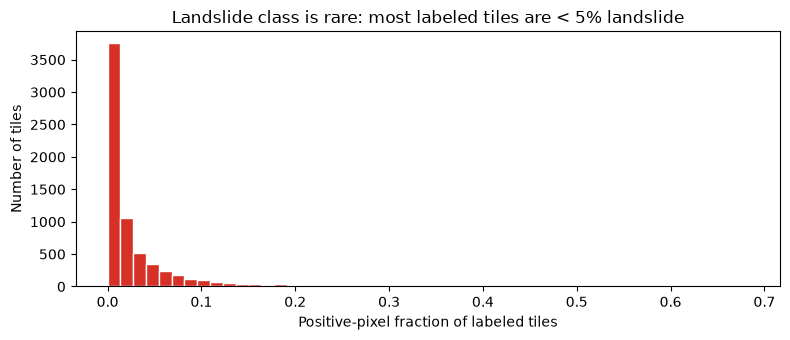

In [5]:
plt.figure(figsize=(8, 3.5))
plt.hist(pos_frac[pos_frac > 0], bins=50, color="#d73027", edgecolor="white")
plt.xlabel("Positive-pixel fraction of labeled tiles")
plt.ylabel("Number of tiles")
plt.title("Landslide class is rare: most labeled tiles are < 5% landslide")
plt.tight_layout()
plt.show()

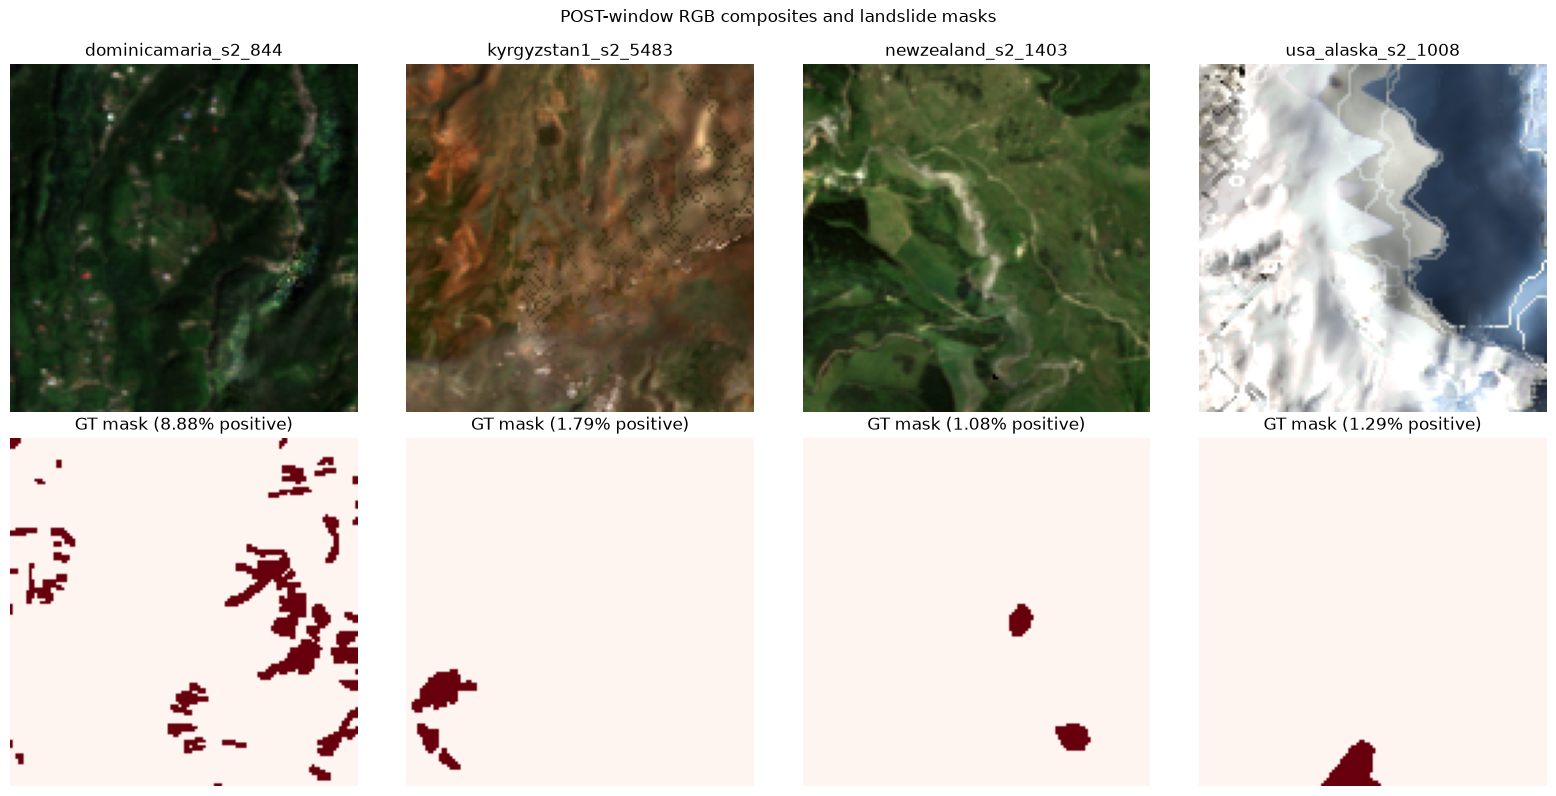

In [6]:
rng = np.random.RandomState(0)
sample = rng.choice([i for i in range(len(files)) if pos_frac[i] > 0.01], 4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, idx in enumerate(sample):
    name = files[idx]
    with h5py.File(os.path.join(PATHS.TRAIN_IMG_DIR, name), "r") as f:
        img = np.array(f["img"])
    with h5py.File(os.path.join(PATHS.TRAIN_MASK_DIR, name), "r") as f:
        mask = np.array(f["mask"])
    rgb = img[1][..., [2, 1, 0]]
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    axes[0, col].imshow(rgb)
    axes[0, col].set_title(name.replace(".h5", ""))
    axes[1, col].imshow(mask.squeeze() > 0.5, cmap="Reds")
    axes[1, col].set_title(f"GT mask ({100*pos_frac[idx]:.2f}% positive)")
    for ax in axes[:, col]:
        ax.axis("off")
fig.suptitle("POST-window RGB composites and landslide masks", y=0.99)
plt.tight_layout()
plt.show()

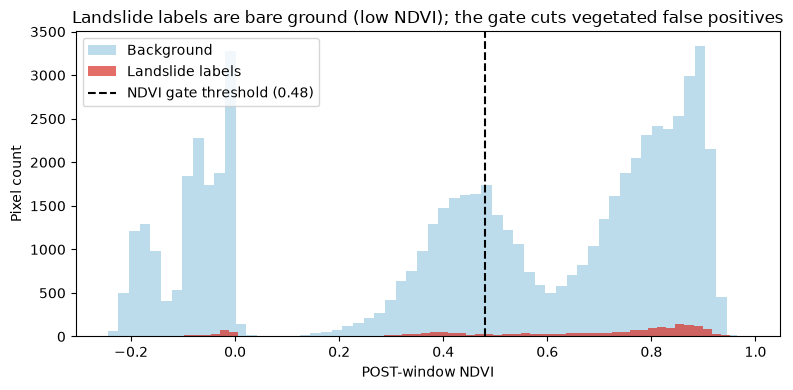

In [7]:
ndvi_pos, ndvi_bg = [], []
for idx in sample:
    name = files[idx]
    with h5py.File(os.path.join(PATHS.TRAIN_IMG_DIR, name), "r") as f:
        ndvi = np.array(f["img"])[1, :, :, 13]
    with h5py.File(os.path.join(PATHS.TRAIN_MASK_DIR, name), "r") as f:
        mask = np.array(f["mask"]) > 0.5
    ndvi_pos.append(ndvi[mask])
    ndvi_bg.append(ndvi[~mask])

plt.figure(figsize=(8, 4))
plt.hist(np.concatenate(ndvi_bg), bins=60, alpha=0.6, label="Background", color="#92c5de")
plt.hist(np.concatenate(ndvi_pos), bins=60, alpha=0.7, label="Landslide labels", color="#d73027")
plt.axvline(0.48, color="black", ls="--", label="NDVI gate threshold (0.48)")
plt.xlabel("POST-window NDVI")
plt.ylabel("Pixel count")
plt.title("Landslide labels are bare ground (low NDVI); the gate cuts vegetated false positives")
plt.legend()
plt.tight_layout()
plt.show()